In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

In [2]:
penguins = sns.load_dataset("penguins").dropna()

# Task 1: Data Prep & Baseline

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
cat_col = penguins.select_dtypes(['object']).columns.to_list()
num_col = penguins.select_dtypes(['int','float']).columns.to_list()
cat_col

['species', 'island', 'sex']

In [5]:
num_col

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [6]:
penguins['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [8]:
le = LabelEncoder()
y = le.fit_transform(penguins['species'])

In [9]:
X = pd.get_dummies(penguins.drop(columns=["species"]), drop_first=True)

In [10]:
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify=y)

In [12]:
scaler = StandardScaler()

In [13]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [14]:
model = LogisticRegression(max_iter=10000, multi_class='multinomial')

In [15]:
model.fit(X_train_scaler, y_train)

LogisticRegression(max_iter=10000, multi_class='multinomial')

In [16]:
y_pred = model.predict(X_test_scaler)

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



The model performs excellent with 99% accuracy. Species 2 (Chinstrap) is the easiest to classify because it has perfect scores (1.00) for both precision and recall. Species 1 (Gentoo) is slightly harder because its precision is 0.93, meaning a few other penguins were mistaken for it. Overall, the features like bill length and body mass clearly distinguish the three groups

# Task 2: Algorithm Comparison

In [34]:
gnb = GaussianNB()
gnb.fit(X_train_scaler, y_train)

GaussianNB()

In [20]:
y_pred_gnb = gnb.predict(X_test_scaler)

In [21]:
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       1.00      0.48      0.65        29
           1       0.58      1.00      0.74        14
           2       0.83      1.00      0.91        24

    accuracy                           0.78        67
   macro avg       0.80      0.83      0.76        67
weighted avg       0.85      0.78      0.76        67



In [22]:
svc_l = SVC(kernel="linear", probability=True)

In [23]:
svc_l.fit(X_train_scaler, y_train)
y_pred_svc_l = svc_l.predict(X_test_scaler)

In [24]:
print(classification_report(y_test, y_pred_svc_l))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [25]:
svc_r  = SVC(kernel="rbf", probability=True)
svc_r.fit(X_train_scaler, y_train)
y_pred_svc_r = svc_r.predict(X_test_scaler)

In [26]:
print(classification_report(y_test, y_pred_svc_r))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [27]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaler, y_train)
y_pred_dtc = dtc.predict(X_test_scaler)

In [28]:
print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        29
           1       0.93      1.00      0.97        14
           2       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



In [29]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_scaler, y_train)
y_pred_rfc = rfc.predict(X_test_scaler)
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [30]:
from sklearn.metrics import f1_score

models = {
    'Logistic Regression': (model, X_test_scaler, y_pred),
    'Naive Bayes': (gnb, X_test_scaler, y_pred_gnb),
    'SVM (linear)': (svc_r, X_test_scaler, y_pred_svc_l),
    'SVM (RBF)': (svc_r, X_test_scaler, y_pred_svc_r),
    'Decision Tree': (dtc, X_test_scaler, y_pred_dtc),
    'Random Forest': (rfc, X_test_scaler, y_pred_rfc),
}

results = []
for name, (model, X_eval, y_pred) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    result = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1': f1_score(y_test, y_pred, average='weighted'),
    }
    results.append(result)

comparison = pd.DataFrame(results)
print("Classification Model Comparison:")
df_results_sorted = comparison.sort_values(by="F1", ascending=False)
df_results_sorted

Classification Model Comparison:


,Model,Accuracy,Precision,Recall,F1
5,Random Forest,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.985075,0.986070,0.985075,0.985201
2,SVM (linear),0.985075,0.986070,0.985075,0.985201
3,SVM (RBF),0.985075,0.986070,0.985075,0.985201
4,Decision Tree,0.955224,0.957214,0.955224,0.955212
1,Naive Bayes,0.776119,0.851175,0.776119,0.760229


Random Forest performed best with a perfect 1.00 F1-score. Logistic Regression and SVM followed closely, showing that this dataset is mostly linearly separable. The only surprise was Naive Bayes, which performed poorly (0.76 F1) because it assumes features are independent, which is not true for penguin body measurements. Overall, tree-based models and linear classifiers are very effective for this data.

# Task 3: Confusion Matrices & ROC Curves

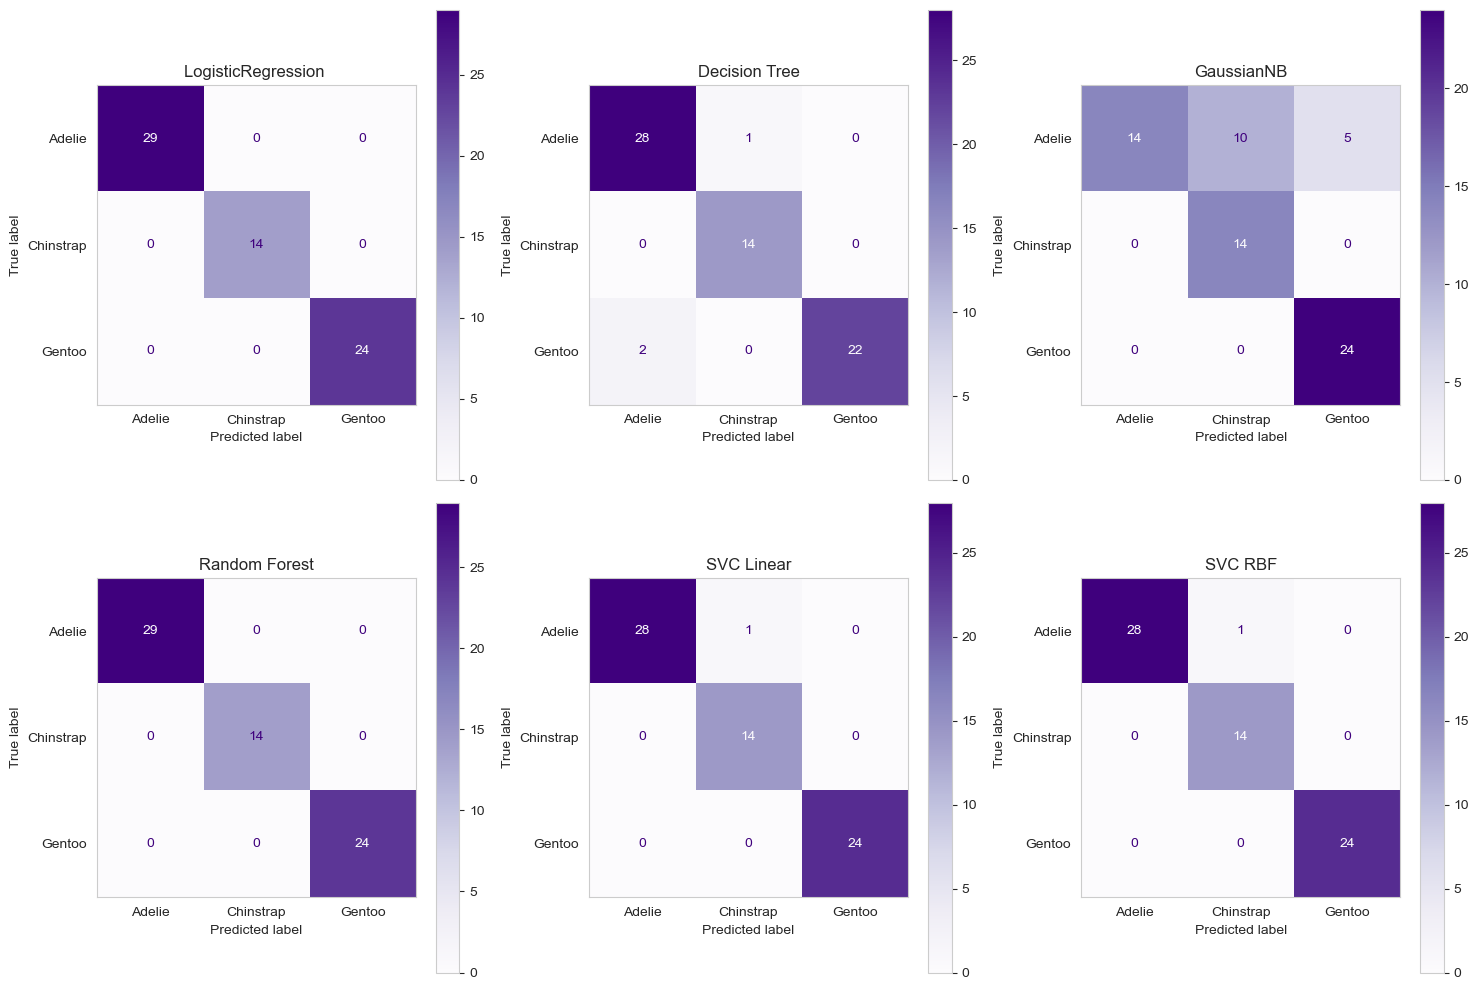

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 

preds = [y_pred, y_pred_dtc, y_pred_gnb, y_pred_rfc, y_pred_svc_l, y_pred_svc_r]
model_names = ["LogisticRegression ", "Decision Tree", "GaussianNB", "Random Forest", "SVC Linear", "SVC RBF"]

for idx, p in enumerate(preds):
    cm = confusion_matrix(y_test, p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], cmap='Purples', values_format='d')
    axes[idx].set_title(model_names[idx])
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

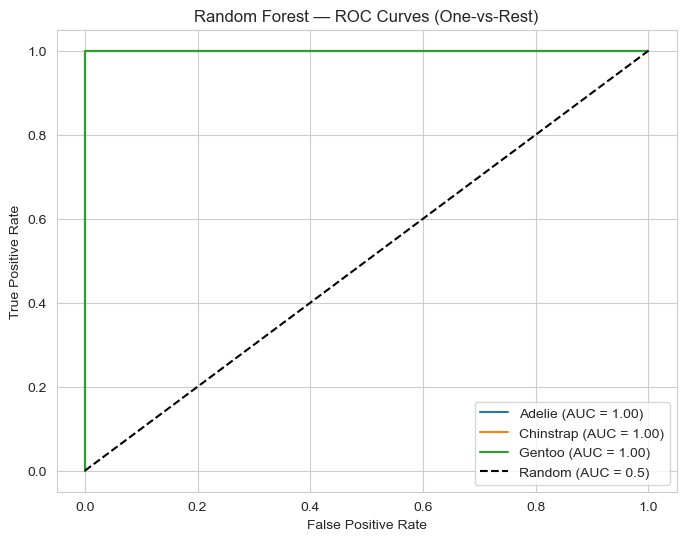

In [32]:
from sklearn.preprocessing import label_binarize
y_test_lb = label_binarize(y_test, classes=[0, 1, 2])
y_prob_rf = rfc.predict_proba(X_test_scaler)

fig, ax = plt.subplots(figsize=(8, 6))

for i, species in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_lb[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{species} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest — ROC Curves (One-vs-Rest)')
ax.legend()
plt.show()

Random Forest is the best model because it has no errors in the confusion matrix and a perfect 1.00 AUC for all species. The confusion matrices show that Adelie and Chinstrap are the hardest to distinguish for weaker models like Naive Bayes. This happens because these two species have similar body sizes and live on the same islands. I recommend Random Forest for this dataset because it handles the features perfectly and provides the most balanced results.

# Task 4: Hyperparameter Exploration

In [33]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring="f1_weighted")

grid_search.fit(X_train_scaler, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaler)
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9962
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



The Random Forest model was tuned using GridSearchCV. The best parameters are n_estimators: 50, max_depth: None, and min_samples_split: 2. The improvement was not significant because the baseline model was already very strong. However, the high Cross-Validation score (0.9962) proves that the model is stable and not just lucky. Even with different class sizes, the model successfully learned to identify all three penguin species perfectly.